# Training Set Image Viewer

Interactive viewer for browsing through the training dataset images and the latest generated-run histograms.

In [1]:
from pathlib import Path

from datasets import load_from_disk
from transformers import PreTrainedTokenizerFast

from dataset_viewer import DatasetViewer
from run_histogram_viewer import collect_histograms, load_latest_run_info, plot_histograms
from seq_length_viewer import compute_seq_lengths, plot_seq_length_distribution

# Project root
project_root = Path.cwd().parent

In [2]:
generated_run_name = "test_v1"  # Name under data/datasets/generated/_runs

dataset = load_from_disk(str(project_root / "data" / "datasets" / "generated" / generated_run_name))
run_info, run_info_path = load_latest_run_info(generated_run_name)
histograms = collect_histograms(run_info)

print(f"Training dataset loaded: {len(dataset)} images")
print(f"Generated run name: {generated_run_name}")
print(f"Latest run info: {run_info_path}")
print(f"Histograms found: {len(histograms)}")

Loading dataset from disk:   0%|          | 0/156 [00:00<?, ?it/s]

Training dataset loaded: 1000 images
Generated run name: test_v1
Latest run info: /home/daniel/.local/share/src/Transcoda/data/datasets/generated/_runs/test_v1/20260410T081924Z-652/info.json
Histograms found: 7


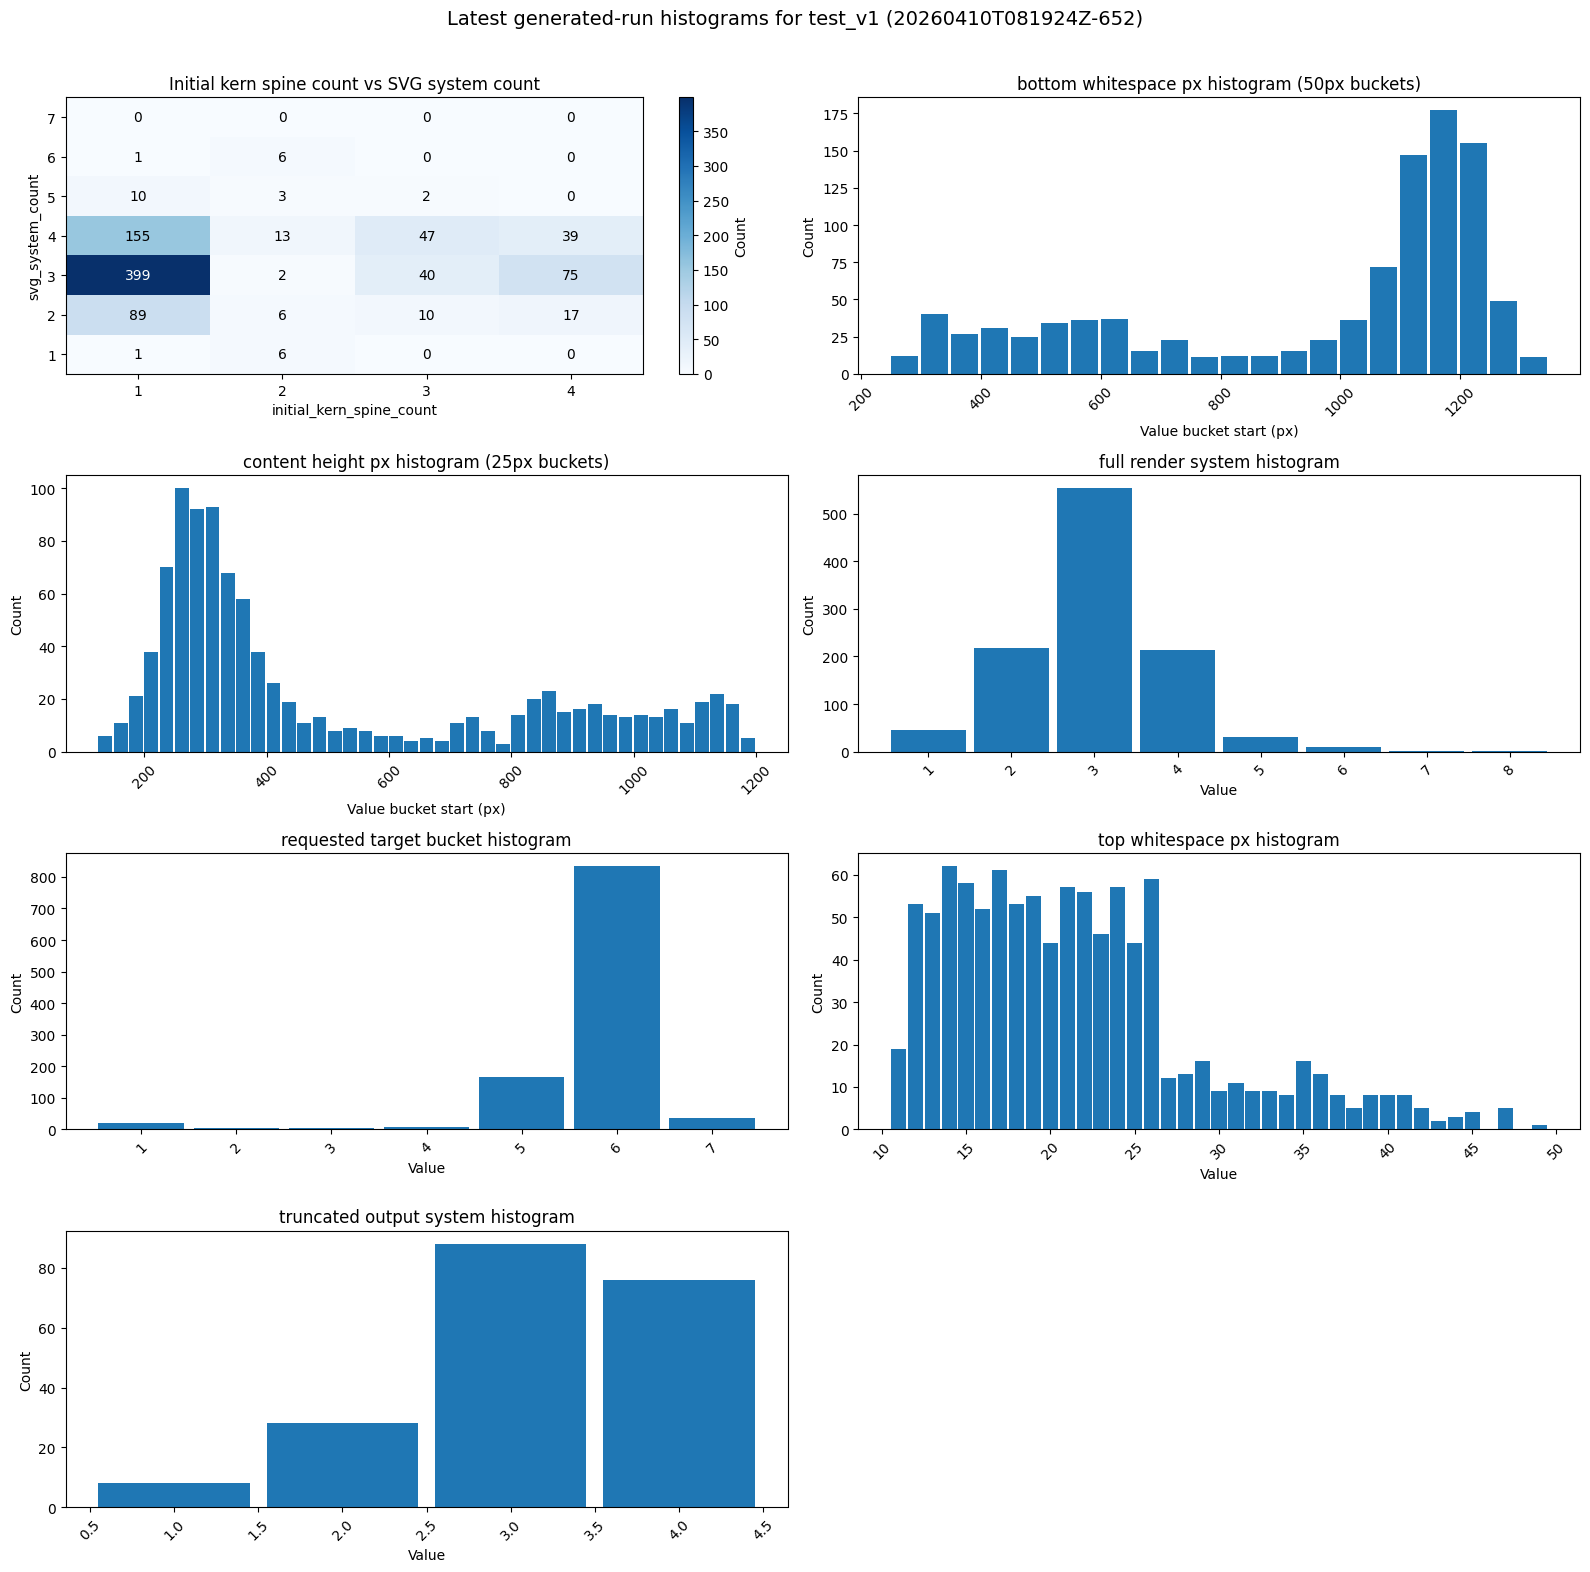

In [3]:
# Plot histograms from the latest generated run
plot_histograms(histograms, dataset_name=generated_run_name, info_path=run_info_path, dataset=dataset)

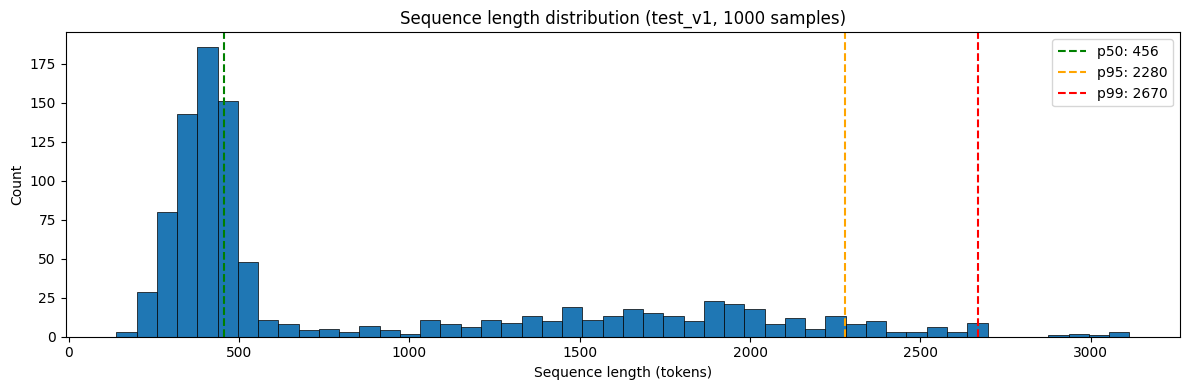

Min: 139  p50: 456  p95: 2280  p99: 2670  Max: 3114  Mean: 860


In [4]:
# Sequence length distribution
tokenizer = PreTrainedTokenizerFast.from_pretrained(str(project_root / "vocab" / "bpe3k-splitspaces"))
seq_lengths = compute_seq_lengths(dataset, tokenizer)
plot_seq_length_distribution(seq_lengths, dataset_name=generated_run_name)

In [ ]:
# Create and show viewer
viewer = DatasetViewer(dataset, title="Training")
viewer.show()

Output()